# Proyecto UCU

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Python para Análisis de Datos

#### Análisis de canciones de Spotify

## 1) Definición del Problema

Contamos con un dataset proveniente de Kaggle que se obtuvo utilizando la API de Spotify. Nuestro objetivo será procesarlo y prepararlo para un eventual modelo de machine learning capaz de predecir la popularidad que tendrá una canción según el resto de sus atributos. Nuestra variable objetivo será _popularity_.

## Paso 2: Recopilación de datos


El dataset previamente obtenido en _import_dataset.ipynb_ se guarda como DataFrame:

In [3]:
df = pd.read_csv("../data/raw/dataset.csv")


Exploración de los campos del dataset:

|     Variable     | Definición                                                                                                                       | Key                                                                                                                |
|:----------------:|:---------------------------------------------------------------------------------------------------------------------------------|:-------------------------------------------------------------------------------------------------------------------|
|   Unnamed: 0   | Índice del registro                                                                                                              |                                                                                                                    |
|     track_id     | Identificador único de la canción                                                                                                |                                                                                                                    |
|     artists      | Intérprete/s                                                                                                                     |                                                                                                                    |
|    album_name    | Nombre del álbum                                                                                                                 |                                                                                                                    |
|    track_name    | Nombre de la canción                                                                                                             |                                                                                                                    |
|    popularity    | Popularidad de la canción                                                                                                        | 0 = Menor popularidad, 100 = Mayor popularidad                                                                     |
|   duration_ms    | Duración de la canción en milisegundos                                                                                           |                                                                                                                    |
|     explicit     | Indica si la canción contiene contenido explícito                                                                                | False = No, True = Sí                                                                                              |
|   danceability   | Bailabilidad (o cualidad de bailable)                                                                                            | 0 = Menos bailable, 1 = Más bailable                                                                               |
|      energy      | Medida de la intensidad de la canción                                                                                            | 0 = Baja energía, 1 = Alta energía                                                                                 |
|       key        | Tonalidad en la que está la canción                                                                                              | 0 = C, 1 = C♯/D♭, 2 = D, 3 = D♯/E♭, 4 = E, 5 = F, 6 = F♯/G♭, 7 = G, 8 = G♯/A♭, 9 = A, 10 = A♯/B♭, 11 = B |
|     loudness     | Volumen de la canción en decibeles (dB)                                                                                          | Valores relativos al máximo digital (0dB)                                                                 |
|       mode       | Indica si la tonalidad de la canción está en modo mayor o menor                                                                  | 0 = Menor, 1 = Mayor                                                                                               |
|   speechiness    | Presencia de palabras habladas en la canción                                                                                     | 0 = Poco contenido hablado, 1 = Mucho contenido hablado                                                            |
|   acousticness   | Métrica musical que mide el nivel de confianza de que la canción utilice sonidos en vivo en lugar de procesados electrónicamente | 0 = Baja probabilidad, 1 = Alta probabilidad                                                                       |
| instrumentalness | Predice si una canción no contiene voces                                                                                         | 0 = Contiene voces, 1 = Instrumental                                                                               |
|     liveness     | Probabilidad de que la grabación haya sido realizada en vivo                                                                     | 0 = Baja probabilidad, 1 = Alta probabilidad                                                                       |
|     valence      | Medida que describe la positividad musical de una canción                                                                        | 0 = Más negativa/triste, 1 = Más positiva/alegre                                                                   |
|      tempo       | Tempo estimado de la canción en pulsaciones o beats por minuto (BPM)                                                             |                                                                                                                    |
|  time_signature  | Compás estimado de la canción                                                                                                    | 3 = 3/4, 4 = 4/4, 5 = 5/4                                                                                          |
|   track_genre    | Género musical de la canción                                                                                                     |                                                                                                                    |

El dataset contiene varios valores que provienen de modelos predictivos de Spotify, por lo que es posible que existan errores y es algo a tener en cuenta en el posterior análisis.

## Paso 3: Análisis Descriptivo

In [4]:
df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


* Se observa que en la columna track_name hay 89741 valores únicos en un dataset con 114000 registros, pero no se trata de un error. Para una misma canción el dataset tiene una fila por cada género de la pista.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

* 3 de las 21 columnas presentan un único dato null.
* El data type detectado para cada columna concuerda con el tipo de dato esperado en todos los casos, pero para las variables key, mode y time_signature podrían redefinirse como variables categóricas.
* La columna "Unnamed: 0" funciona como identificador.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


* Dado que una canción aparece tantas veces como la cantidad de géneros que tenga (_track_genre_), las medidas estadísticas se ven afectadas en todos los campos se ven afectadas por la repetición de registros.
* Se detectan algunas incongruencias como los mínimos iguales a 0.000 para duration_ms y tempo.
* Se procede a identificar la cantidad de valores "0" en cada columna.

In [7]:
(df == 0).sum().sort_values(ascending=False)

explicit            104253
mode                 41319
instrumentalness     38763
popularity           16020
key                  13061
valence                176
time_signature         163
tempo                  157
danceability           157
speechiness            157
acousticness            39
liveness                 2
Unnamed: 0               1
duration_ms              1
energy                   1
artists                  0
track_id                 0
track_name               0
album_name               0
loudness                 0
track_genre              0
dtype: int64

* En algunas de estas columnas, los valores iguales a "0" están dentro de lo esperado. Por ejemplo para _mode_ que es una variable booleana, un valor de cero corresponde a una canción en tonalidad menor. Sin embargo, esto no tiene sentido para las columnas _valence_, _tempo_ y _danceability_, por lo que es algo a considerar al utilizar estos campos para relacionarlos con el resto.
* Procedemos a buscar filas con datos nulos (que en df.info() ya habíamos visto que solo había en tres columnas):

In [8]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [9]:
df[df.isnull().any(axis=1)]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


* Los tres nulos en las columnas _artists_, _album_name_ y _track_name_ corresponden a la misma fila.

* Continuamos buscando duplicados:

In [16]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
113995    False
113996    False
113997    False
113998    False
113999    False
Length: 114000, dtype: bool

* No se encontraron duplicados. Podemos extender la búsqueda filtrando la columna track_id para evaluar si hay dos canciones con diferente track_id pero igual contenido (la misma canción con los mismos valores pero asignada a dos track_id diferentes):

In [17]:

df.duplicated(subset=df.columns.difference(['track_id'])).sum()

np.int64(0)

* Ninguna canción aparece más de una vez con diferente track_id.

* Continuamos explorando la variable _track_genre_:

In [14]:
df["track_genre"].value_counts()

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

* Este dataset contiene 114.000 registros, 114 _track_genre_ posibles y 1000 filas para cada género. Esto viene de un diseño intencional del dataset donde se buscó que cada género tuviese la misma representación, pero conlleva a perder la popularidad real de cada género en la plataforma (no podemos observar la distribución relativa de cada género).
* Cabe destacar que en el dataset no solamente aparecen canciones, sino que también existen registros correspondientes a rutinas de _Stand Up_. Por el punto anterior sabemos que hay 1000 filas con este género, pero debemos distinguir cuáles son canciones y cuáles no.
    De la documentación oficial de la API de Spotify:

**Speechiness** detecta la presencia de palabras habladas en una pista. Cuanto más exclusivamente se parezca la grabación al habla (por ejemplo, un programa de entrevistas, un audiolibro o poesía), más cercano a **1,0** será el valor del atributo.

| Valor           | Interpretación                                                                                                                   |
| --------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| **> 0,66**      | Pistas que probablemente están compuestas casi completamente por palabras habladas.                                              |
| **0,33 – 0,66** | Pistas que pueden contener tanto música como habla, ya sea en distintas secciones o superpuestas. Incluye casos como el **rap**. |
| **< 0,33**      | Pistas que probablemente corresponden a música u otros contenidos sin características similares al habla.                        |

Con esta información podemos fijar en principio un umbral de 0,66 y graficar la cantidad de filas vs _speechiness_ (dentro del género comedy):

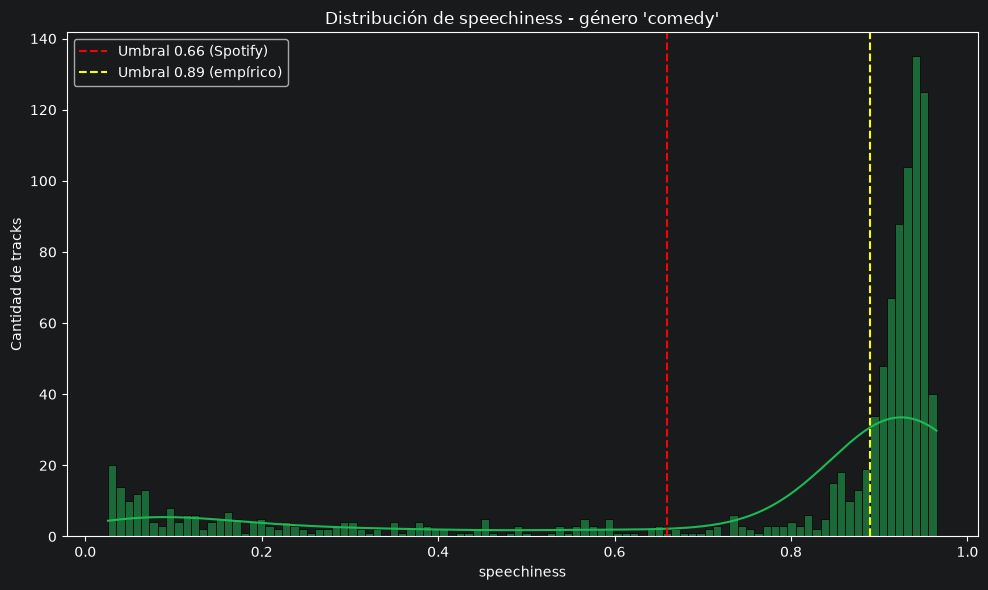

In [41]:
comedy = df[df["track_genre"] == "comedy"]
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(comedy["speechiness"], bins=100, kde=True, color="#1DB954", ax=ax)
ax.axvline(0.66, color="red", linestyle="--", label="Umbral 0.66 (Spotify)")
ax.axvline(0.89, color="yellow", linestyle="--", label="Umbral 0.89 (empírico)")
ax.set_title("Distribución de speechiness - género 'comedy'")
ax.set_xlabel("speechiness")
ax.set_ylabel("Cantidad de tracks")
ax.legend()
plt.tight_layout()
plt.show()

* En base al salto alrededor de 0,89, podemos suponer que el incremento en cantidad de tracks se debe a un nuevo grupo de contenido (diferente de canciones y probablemente rutinas de Stand Up) y fijar un nuevo umbral para realizar el filtrado en el paso posterior.

## Paso 4: Limpieza de Datos



* Se eliminaron las 176 filas que presentaban un valor igual a 0 en al menos una de las variables _tempo_, _danceability_ o _valence_ ya que un valor "0" en alguna de estas variables puede dificultar o distorsionar la comparación entre canciones. Tratándose de un dataset con más de 100.000 registros, se considera que la eliminación de estas filas no es de impacto significativo. En otra instancia se podría haber completado los valores de _tempo_ (en caso de estar disponible como dato público), pero no los de _danceability_ o _valence_ dado que provienen de algoritmos de Spotify).
* También se decidió eliminar la fila que contenía datos nulos por el mismo motivo.

In [10]:
df_clean = df.copy()

In [11]:
filas_cero = (
    (df_clean["tempo"] == 0) |
    (df_clean["danceability"] == 0) |
    (df_clean["valence"] == 0)
)

filas_cero.sum()

np.int64(176)

In [12]:
df_clean.drop(df_clean[filas_cero].index, inplace=True) # Se eliminan las 176 filas con valores iguales a cero incongruentes.

In [13]:
df_clean.drop(65900, axis=0, inplace=True) # Se elimina la fila con datos fantasma.

* Dado que una canción puede aparecer tantas veces como el número de géneros registrados que tenga, se decide agrupar los valores de track_genre. De esta forma no se pierde información si se realiza un filtro de duplicados por track_id.

In [22]:
generos_agrupados = df_clean.groupby('track_id')['track_genre'].apply(lambda x: list(x.unique()))
df_clean = df_clean.drop_duplicates(subset=['track_id']).drop(columns=['track_genre'])
df_clean = df_clean.merge(generos_agrupados, on='track_id')

## Paso 5: Análisis de Variables - EDA

#### Análisis de Variables Univariante Categóricas
Para este dataset, las variables categóricas son

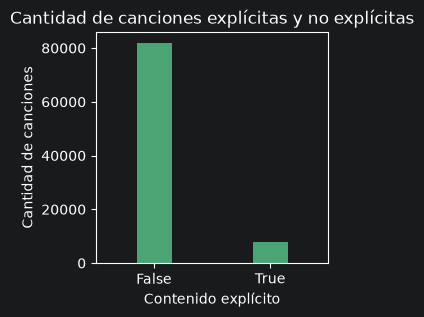

In [23]:
plt.figure(figsize=(3, 3))

sns.countplot(
    data=df_clean,
    x="explicit",
    color="mediumseagreen",
    width=0.3                # barras más finas
)

plt.title("Cantidad de canciones explícitas y no explícitas")
plt.xlabel("Contenido explícito")
plt.ylabel("Cantidad de canciones")

plt.show()

* Se observa una predominancia de canciones sin contenido explicito


In [24]:
variables = ["popularity", "duration_ms", "danceability", "energy", "loudness", "speechiness","acousticness", "instrumentalness", "liveness", "valence", "tempo"]

correlacion = df_clean[variables].corr()

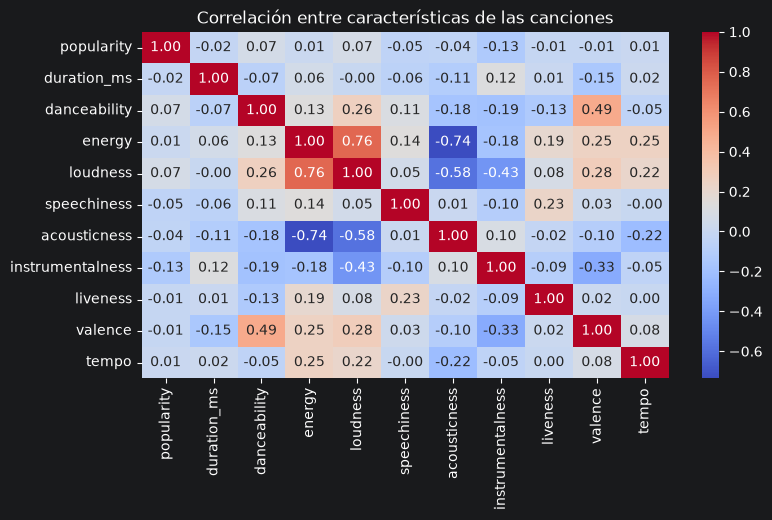

In [25]:
plt.figure(figsize=(8.5, 4.5))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlación entre características de las canciones")
plt.show()

* Se halló que las variables energy y loudness se encuentran relacionadas (0.76), lo que indicaría que las canciones con mas energía tienden a tener mayor intensidad sonora.
* También se observa una relación negativa entre energy y acousticness (-0.74), por lo que se entiende que las canciones más acústicas tienen menor energía.
 * Otra relación relevante es danceability con valence (0.47), lo que sugiere que las canciones más bailables suelen ser mas positivas.
  * La popularidad no muestra una dependencia significativa con ninguna de las otras variables (apenas una pequeña tendencia negativa (-0.10) con instrumentalness, indicando que el contenido "menos hablado" tiene menor tracción en la plataforma).

## Paso 6: Ingeniería de características


In [47]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,89564.0,53397.333527,33380.661382,0.00000,23726.75000,50603.500000,80478.2500,113999.000
popularity,89564.0,33.192689,20.593082,0.00000,19.00000,33.000000,49.0000,100.000
duration_ms,89564.0,229274.670537,111749.310177,17826.00000,173173.00000,213400.000000,264381.5000,5237295.000
danceability,89564.0,0.563227,0.175198,0.05130,0.45100,0.576000,0.6920,0.985
energy,89564.0,0.635468,0.255609,0.00002,0.45900,0.677000,0.8530,1.000
key,89564.0,5.283507,3.559225,0.00000,2.00000,5.000000,8.0000,11.000
loudness,89564.0,-8.472333,5.174641,-46.59100,-10.30300,-7.177000,-5.1030,4.532
mode,89564.0,0.636874,0.480903,0.00000,0.00000,1.000000,1.0000,1.000
speechiness,89564.0,0.087571,0.113304,0.02210,0.03600,0.049000,0.0860,0.965
acousticness,89564.0,0.327958,0.338081,0.00000,0.01710,0.188000,0.6240,0.996


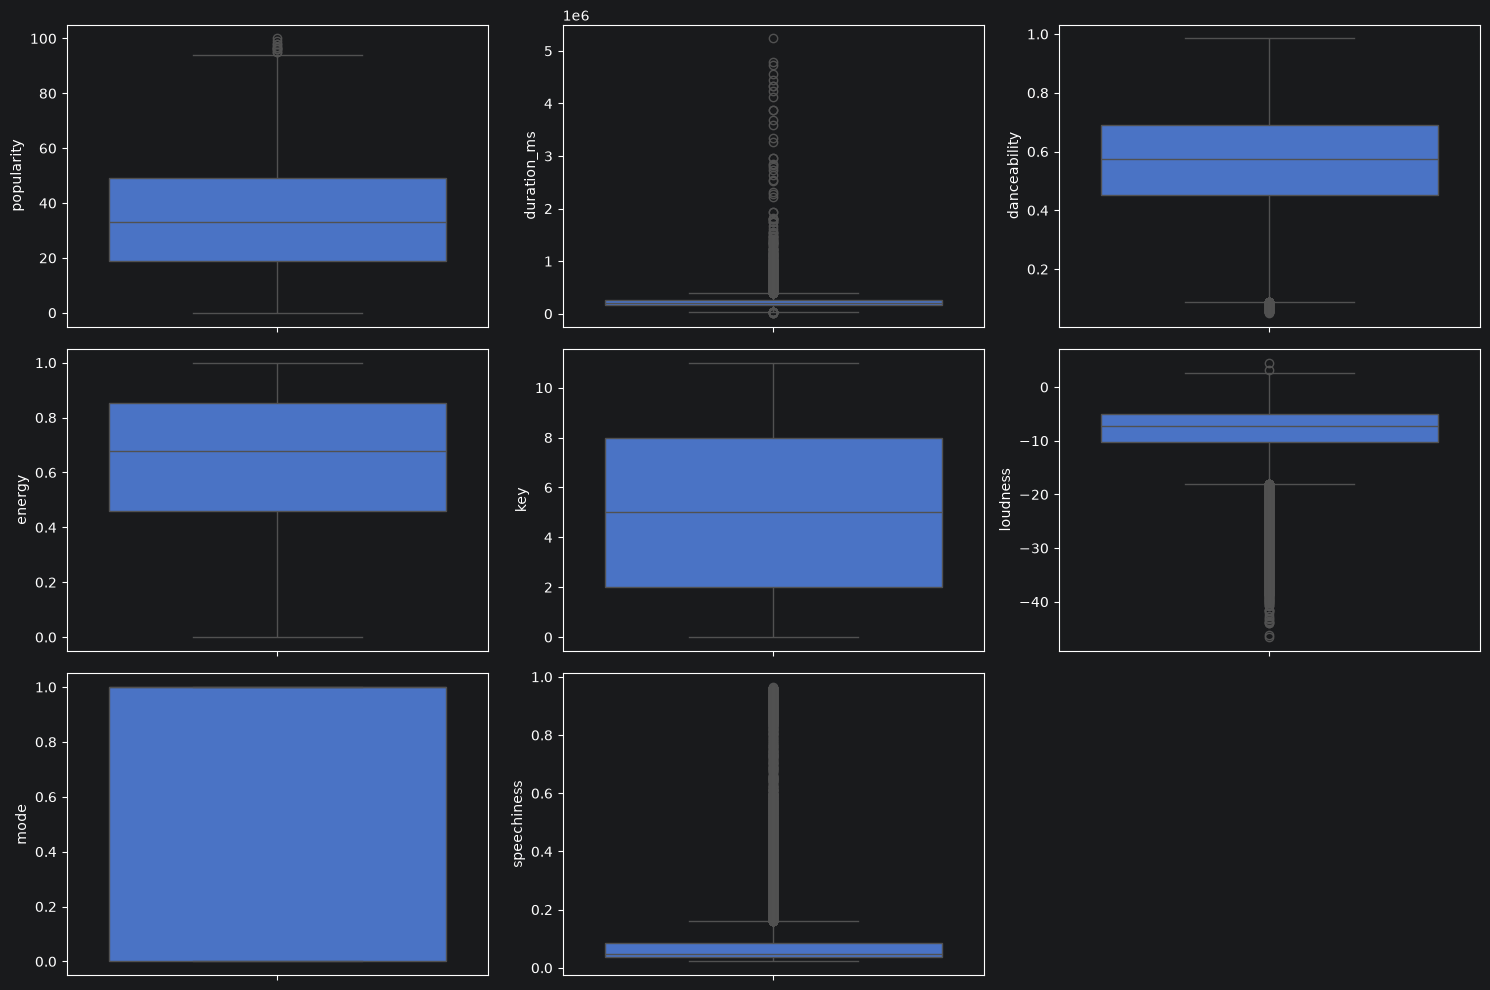

In [48]:
fig, axis = plt.subplots(3, 3, figsize=(15, 10))

sns.boxplot(ax=axis[0, 0], data=df_clean, y="popularity")
sns.boxplot(ax=axis[0, 1], data=df_clean, y="duration_ms")
sns.boxplot(ax=axis[0, 2], data=df_clean, y="danceability")
sns.boxplot(ax=axis[1, 0], data=df_clean, y="energy")
sns.boxplot(ax=axis[1, 1], data=df_clean, y="key")
sns.boxplot(ax=axis[1, 2], data=df_clean, y="loudness")
sns.boxplot(ax=axis[2, 0], data=df_clean, y="mode")
sns.boxplot(ax=axis[2, 1], data=df_clean, y="speechiness")
sns.boxplot(ax=axis[2, 2], data=df_clean, y="acousticness")
fig.delaxes(axis[2, 2])

plt.tight_layout()
plt.show()

## Observaciones

Popularity, Key, Loudness y Speechiness son las afectadas por Outliers

### Popularity

In [40]:
popularity_stats = df_clean["popularity"].describe()
popularity_stats

count    89564.000000
mean        33.192689
std         20.593082
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64

In [52]:
# Calculo el Rango inter Cuartil: IQR = Q3(75%) - Q1(25%)
q1 = df_clean["popularity"].quantile(0.25)
q3 = df_clean["popularity"].quantile(0.75)
iqr = q3 - q1

# Definir los límites inferior y superior
lower_limit = 0 if (q1 - 1.5 * iqr) < 0 else q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

f"Límites superior: {round(upper_limit, 2)}, límite inferior: {round(lower_limit, 2)}, rango intercuartílico: {round(iqr, 2)}"

'Límites superior: 94.0, límite inferior: 0, rango intercuartílico: 30.0'

In [53]:
df_clean[df_clean["popularity"] > upper_limit]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
18901,20000,5IgjP7X4th6nMNDh4akUHb,Chris Brown,Indigo (Extended),Under The Influence,96,184613,True,0.733,0.690,...,-5.529,0,0.0427,0.06350,0.000001,0.1050,0.310,116.992,4,"[dance, pop]"
18902,20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,"[dance, pop]"
18909,20008,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,"[dance, edm, pop]"
45770,51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,...,-5.548,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,[hip-hop]
57089,67356,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,"[latin, latino, reggae, reggaeton]"
57091,67358,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,...,-5.105,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,"[latin, latino, reggae, reggaeton]"
57092,67359,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,False,0.650,0.715,...,-5.198,0,0.2530,0.09930,0.000291,0.1260,0.187,106.672,4,"[latin, latino, reggae, reggaeton]"
57230,67500,3k3NWokhRRkEPhCzPmV8TW,Bad Bunny;Bomba Estéreo,Un Verano Sin Ti,Ojitos Lindos,95,258298,False,0.647,0.686,...,-5.745,0,0.0413,0.08000,0.000001,0.5280,0.268,79.928,4,"[latin, latino, reggae, reggaeton]"
57271,67559,5Eax0qFko2dh7Rl2lYs3bx,Bad Bunny,Un Verano Sin Ti,Efecto,96,213061,False,0.801,0.475,...,-8.797,0,0.0516,0.14100,0.000017,0.0639,0.234,98.047,4,"[latin, latino, reggae, reggaeton]"
65987,79000,4h9wh7iOZ0GGn8QVp4RAOB,OneRepublic,I Ain’t Worried (Music From The Motion Picture...,I Ain't Worried,96,148485,False,0.704,0.797,...,-5.927,1,0.0475,0.08260,0.000745,0.0546,0.825,139.994,4,"[piano, pop, rock]"


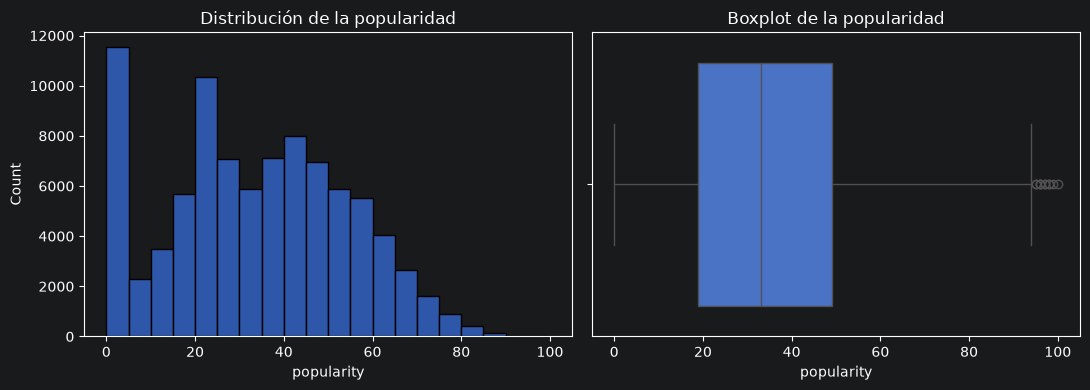

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(
    data=df_clean,
    x="popularity",
    bins=20,
    ax=axes[0]
)
axes[0].set_title("Distribución de la popularidad")

sns.boxplot(
    data=df_clean,
    x="popularity",
    ax=axes[1]
)
axes[1].set_title("Boxplot de la popularidad")

plt.tight_layout()
plt.show()

#### Conclusiones

La variable popularidad, se encuentra definida en una escala de 0 a 100. El método del rango intercuartílico puede señalar las canciones con popularidad 100 como valores atípicos debido a que son poco frecuentes dentro de la distribución. Sin embargo, estos valores respetan el dominio de la variable y representan observaciones posibles, por lo que se decide conservarlos. También se mantienen los valores iguales a 0, ya que representan canciones con mínima popularidad y no datos faltantes.

### Loudness

loudness representa la intensidad sonora promedio de una canción, medida en decibeles.

valores cercanos a 0 representan canciones más intensas;
valores muy negativos representan canciones más silenciosas;

In [55]:
loudness_stats = df_clean["loudness"].describe()
loudness_stats

count    89564.000000
mean        -8.472333
std          5.174641
min        -46.591000
25%        -10.303000
50%         -7.177000
75%         -5.103000
max          4.532000
Name: loudness, dtype: float64

In [57]:
# Calculo el Rango inter Cuartil: IQR = Q3(75%) - Q1(25%)
q1 = df_clean["loudness"].quantile(0.25)
q3 = df_clean["loudness"].quantile(0.75)
iqr = q3 - q1

# Definir los límites inferior y superior
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

f"Límites superior: {round(upper_limit, 2)}, límite inferior: {round(lower_limit, 2)}, rango intercuartílico: {round(iqr, 2)}"

'Límites superior: 2.7, límite inferior: -18.1, rango intercuartílico: 5.2'

In [58]:
loudness_outliers = df_clean[
    (df_clean["loudness"] < lower_limit) |
    (df_clean["loudness"] > upper_limit)
]

cantidad = loudness_outliers.shape[0]
porcentaje = cantidad / df_clean.shape[0] * 100

print(f"Cantidad de outliers: {cantidad}")
print(f"Porcentaje de outliers: {porcentaje:.2f}%")

Cantidad de outliers: 4927
Porcentaje de outliers: 5.50%


In [62]:
outliers_inferiores = df_clean[
    df_clean["loudness"] < lower_limit
]

outliers_superiores = df_clean[
    df_clean["loudness"] > upper_limit
]

print(f"Outliers inferiores: {len(outliers_inferiores)}")
print(f"Outliers superiores: {len(outliers_superiores)}")

outliers_inferiores[
    ["track_name", "artists", "loudness", "track_genre"]
].sort_values("loudness").head(10)




Outliers inferiores: 4925
Outliers superiores: 2


,track_name,artists,loudness,track_genre
80526,Ceiling Fan Sound on Low Power,Atmosphere Asmr,-46.591,[sleep]
80235,Cricket Sound 4 - Loopable With No Fade,White Noise for Babies;Crickets;Baby Sleep Sounds,-46.251,[sleep]
66548,Chaconne in sol maggiore : Variazione 9,Lazar Berman,-43.957,[piano]
80739,Nap in the Afternoon Box Fan,Binaural Beats;White Noise Babies;Binaural Bea...,-43.943,[sleep]
80736,Loopable Woods,Relaxing Music Therapy;4D Nature Recordings;Cr...,-43.714,[sleep]
80326,Sleep Sound For Babies - Underwater,Wave Sounds For Sleep,-43.504,[sleep]
66446,Wake with me,Brian Lyndon,-43.303,[piano]
89093,Sonidos de Aves,Sonidos De Aves,-43.043,[world-music]
80345,"White Noise - Hi Res 178,9 hz",Granular,-42.631,[sleep]
35654,Message from Home,Hans Zimmer,-42.044,[german]


In [63]:
outliers_superiores[
    ["track_name", "artists", "loudness", "track_genre"]
].sort_values("loudness", ascending=False).head(10)

,track_name,artists,loudness,track_genre
16544,Fate Dance,Five Star Hotel,4.532,[club]
50735,Islamic Capitalism,Najand,3.156,[iranian]


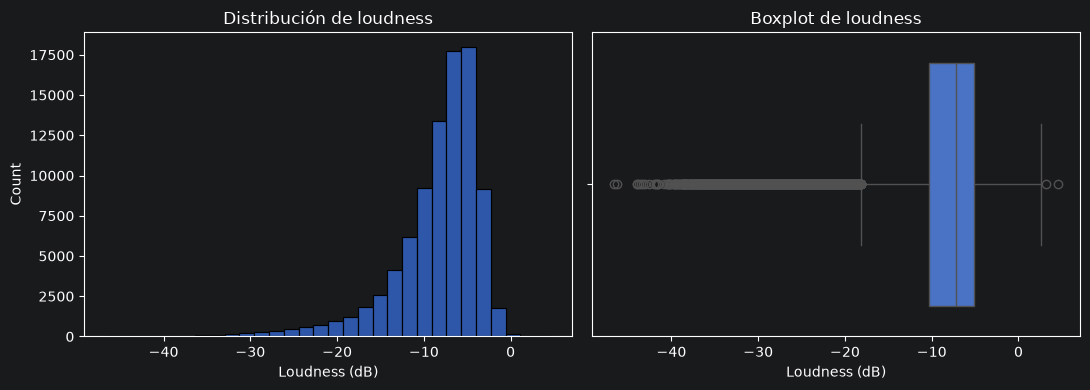

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(
    data=df_clean,
    x="loudness",
    bins=30,
    ax=axes[0]
)
axes[0].set_title("Distribución de loudness")
axes[0].set_xlabel("Loudness (dB)")

sns.boxplot(
    data=df_clean,
    x="loudness",
    ax=axes[1]
)
axes[1].set_title("Boxplot de loudness")
axes[1].set_xlabel("Loudness (dB)")

plt.tight_layout()
plt.show()

In [54]:
df_clean[df_clean["loudness"] > 2]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
16544,17574,0HfHtjS9S9q4DGVC3uIIRB,Five Star Hotel,Gray Data,Fate Dance,16,237000,False,0.310,0.999,...,4.532,0,0.3430,0.000102,0.945000,0.148,0.0333,160.040,4,[club]
34989,38840,7K0pkS5lqUkFd9kuY0spiK,The Red Pears,We Bring Anything to the Table... Except Table...,Time Bomb,25,176065,False,0.442,0.800,...,2.574,1,0.0686,0.262000,0.000001,0.664,0.3690,118.053,4,[garage]
50735,59225,5rm5Zqktf6v3u9yGj6RR5W,Najand,In the Night of Revolution,Islamic Capitalism,0,60056,False,0.149,0.868,...,3.156,0,0.0767,0.191000,0.865000,0.625,0.0494,136.188,3,[iranian]


#### Conclusiones

Se identificaron 4.927 registros potencialmente atipicos lo cual equivale a 5,5% del dataset, debido a que representa una porcion relevante, su eliminacion podria alterar la representacion de determinados generos musicales.
ademas esto no implica que el valor sea incorrecto.

### Speechiness

Esta variable mide a presencia de palabras habladas en una canción.
Cuanto mas alto el valor mayor es la presencia de contenido hablado en la cancion.


In [64]:
speechiness_stats = df_clean["speechiness"].describe()
speechiness_stats

count    89564.000000
mean         0.087571
std          0.113304
min          0.022100
25%          0.036000
50%          0.049000
75%          0.086000
max          0.965000
Name: speechiness, dtype: float64

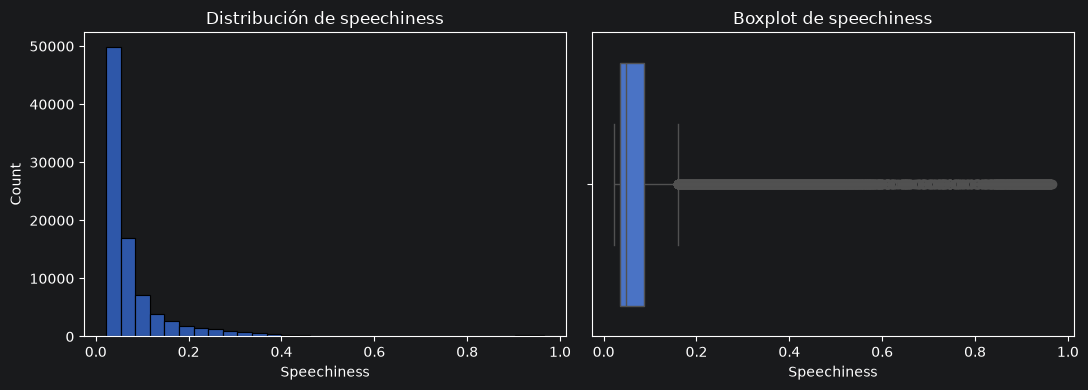

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(
    data=df_clean,
    x="speechiness",
    bins=30,
    ax=axes[0]
)
axes[0].set_title("Distribución de speechiness")
axes[0].set_xlabel("Speechiness")

sns.boxplot(
    data=df_clean,
    x="speechiness",
    ax=axes[1]
)
axes[1].set_title("Boxplot de speechiness")
axes[1].set_xlabel("Speechiness")

plt.tight_layout()
plt.show()

In [73]:
q1 = df_clean["speechiness"].quantile(0.25)
q3 = df_clean["speechiness"].quantile(0.75)
iqr = q3 - q1

statistical_lower_limit = q1 - 1.5 * iqr
statistical_upper_limit = q3 + 1.5 * iqr

lower_limit = max(0, statistical_lower_limit)
upper_limit = min(1, statistical_upper_limit)

f"Límites superior: {round(upper_limit, 4)}, límite inferior: {round(lower_limit, 4)}, rango intercuartílico: {round(iqr, 4)}"


'Límites superior: 0.161, límite inferior: 0, rango intercuartílico: 0.05'

In [77]:
speechiness_outliers = df_clean[
    (df_clean["speechiness"] < lower_limit) |
    (df_clean["speechiness"] > upper_limit)
]

cantidad = speechiness_outliers.shape[0]
porcentaje = cantidad / df_clean.shape[0] * 100

f"Cantidad de outliers: {cantidad},Porcentaje de outliers: {porcentaje:.2f} %"

'Cantidad de outliers: 10635,Porcentaje de outliers: 11.87 %'

In [80]:
df_clean.explode("track_genre").groupby(
    "track_genre"
)["speechiness"].median().sort_values(ascending=False).head(15)

track_genre
comedy         0.91700
j-dance        0.22000
dancehall      0.15600
grindcore      0.12300
hardcore       0.10600
death-metal    0.09530
hip-hop        0.09480
kids           0.09350
metalcore      0.09190
reggaeton      0.08710
latino         0.08600
happy          0.08280
hardstyle      0.08270
sad            0.08165
reggae         0.08130
Name: speechiness, dtype: float64

#### Conclusion

Se ientificarion como outliers  un 11.87 % de las canciones, sin embargo se encuentran entre el rango valido de valores.
analizando el genero de estas canciones se encuentra qeu la mayoria corresponde al genero Comedy, por este motivo se considera que representan caracteristicas reales del genero y no son errores en los datos.

debido a esto se mantiene en el dataset.

## Paso 7: Split (dos métodos o enfoques)

## Paso 8: Scaling & Encoding

### Guardamos el DS Procesado

In [83]:
os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv("../data/processed/spotify_processed.csv", index=False)

## Paso 9: Selección de características

# Resumen